#### **ANÁLISIS EXPLORATORIO DE DATOS (EDA)**

In [439]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

catalogo_productos = pd.read_csv("Datos-finales/catalogo_productos.csv")
especificaciones_cajas = pd.read_csv("Datos-finales/especificaciones_cajas.csv")
operaciones_planta = pd.read_csv("Datos-finales/operaciones_planta.csv")
procurement_cajas = pd.read_csv("Datos-finales/procurement_cajas.csv")

#### **1. Estadísticas de productos**

In [440]:
cantidad_productos = catalogo_productos['codigo_producto'].nunique()
print(f"Hay {cantidad_productos}/{len(catalogo_productos)} productos únicos.")

Hay 421/435 productos únicos.


Veamos en particular cuáles productos se repiten y cuántas veces. Intuimos que esto significa que para dichos casos, un mismo producto puede utilizar un tipo de caja distinto y ser enviados a distintas regiones.

In [441]:
repetidos = catalogo_productos['codigo_producto'].value_counts()
repetidos = repetidos[repetidos > 1]  
print(repetidos)

codigo_producto
BR0092    2
BR0209    2
BR0094    2
BR0195    2
BR0136    2
BR0189    2
BR0193    2
BR0253    2
BR0310    2
BR0314    2
BR0332    2
BR0334    2
BR0340    2
BR0341    2
Name: count, dtype: int64


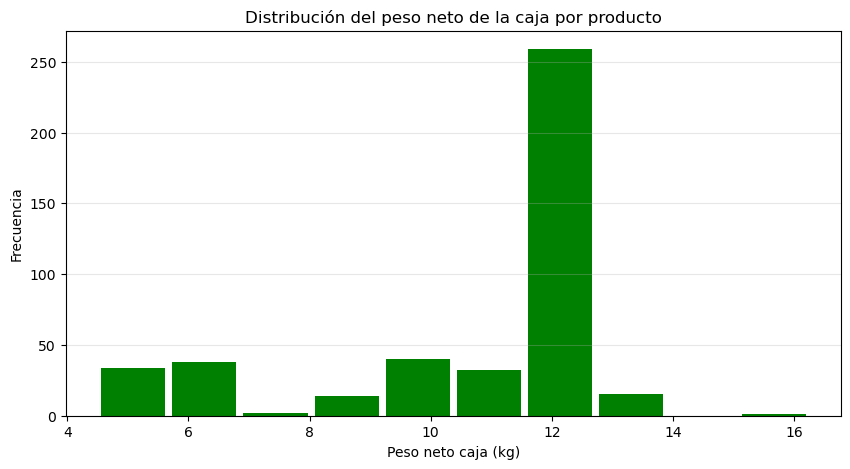

In [442]:
plt.figure(figsize=(10, 5))
plt.hist(catalogo_productos['peso_neto_caja'].dropna(), bins=10,
         color='green', rwidth=0.9)
plt.title('Distribución del peso neto de la caja por producto')
plt.xlabel('Peso neto caja (kg)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

#### **2. Estadísticas de cajas**

In [443]:
cantidad_cajas = especificaciones_cajas['caja_tipo_id'].nunique()
print(f"Hay {cantidad_cajas}/{len(especificaciones_cajas)} tipos de cajas únicos.")

Hay 204/204 tipos de cajas únicos.


In [444]:
print("TOP 5 tipos de cajas con más utilización de pallet")
print("-" * 55)
top_pallet = especificaciones_cajas.groupby('caja_tipo_id')['utilizacion'].mean().nlargest(5)
print(top_pallet)

print("\nTOP 5 tipos de cajas con menos utilización de pallet")
print("-" * 55)
worst_pallet = especificaciones_cajas.groupby('caja_tipo_id')['utilizacion'].mean().nsmallest(5)
print(worst_pallet)

TOP 5 tipos de cajas con más utilización de pallet
-------------------------------------------------------
caja_tipo_id
bd62436e72b572461e548cf6e4bfdd7d    0.986888
b2a1bd10e103dae56072fe8ba4f0ca15    0.977213
e0f0d757e0995cc6d8f42ce6a520228e    0.976620
45d3118bfae802ddfa0399a8135c2361    0.976183
42df43cac5362b6b332e67057aac0554    0.975856
Name: utilizacion, dtype: float64

TOP 5 tipos de cajas con menos utilización de pallet
-------------------------------------------------------
caja_tipo_id
1d53cb238c8997b85dde2badf022947f    0.717528
7d5bf7157bac4cddab76a52a1d8dd41d    0.723668
f5bd804a90f4512d522129ccb62d549f    0.734352
4a996ddd03e81fc2dbda07eb0ca1135d    0.737715
c8898fc66f1c4e56f02718e10a4dc36b    0.743923
Name: utilizacion, dtype: float64


In [445]:
cajas_usadas = catalogo_productos['caja_tipo_id'].value_counts()
especificaciones_cajas['num_productos'] = especificaciones_cajas['caja_tipo_id'].map(
    cajas_usadas
)

print("TOP 5 tipos de cajas con más número de productos")
print("-" * 55)
top_num_prod = especificaciones_cajas.groupby('caja_tipo_id')['num_productos'].mean().nlargest(5)
print(top_num_prod)


TOP 5 tipos de cajas con más número de productos
-------------------------------------------------------
caja_tipo_id
ef0525f0911fd36073c2b10f4d81dfd5    11.0
dbb291248e849bc6807762eb48e5f5cf     8.0
6ecff7742d4a01e1ada1f078a109ba73     7.0
bee1ee50d857c700c72bb718c6f645db     7.0
c8c092bbf8da5f80452c66c38d27305f     7.0
Name: num_productos, dtype: float64


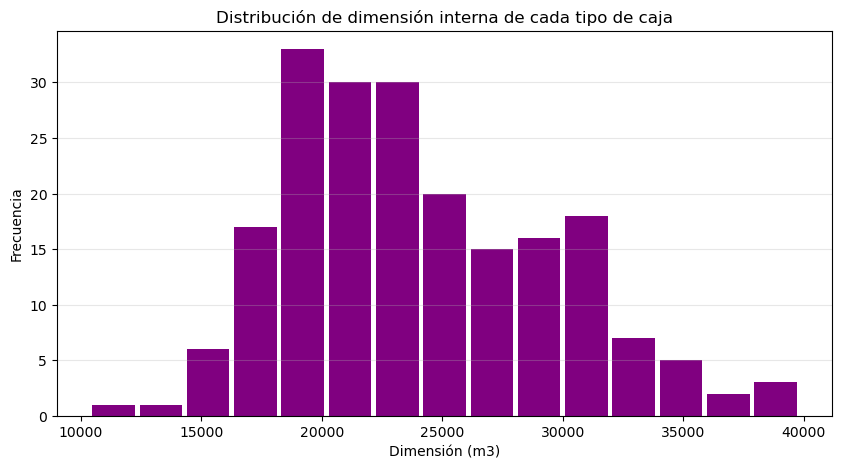

In [446]:
cajas_dimension = especificaciones_cajas['dimension_interna'] / 1000
plt.figure(figsize=(10, 5))
plt.hist(cajas_dimension.dropna(), bins=15,
         color='purple', rwidth=0.9)
plt.title('Distribución de dimensión interna de cada tipo de caja')
plt.xlabel('Dimensión (m3)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

Entender cómo se distribuye la dimensión interna de cada tipo de caja es crucial en el problema.

Como la diferencia entre la dimensión interna original y la nueva no puede excederse de 10%, solamente podemos reelegir para cada producto un tipo de caja con dimensión similar al anterior. Esto nos restringe claramente la cantidad de tipos de caja que podemos utilizar para cada producto.

#### **3. Utilización de caja y pallet**

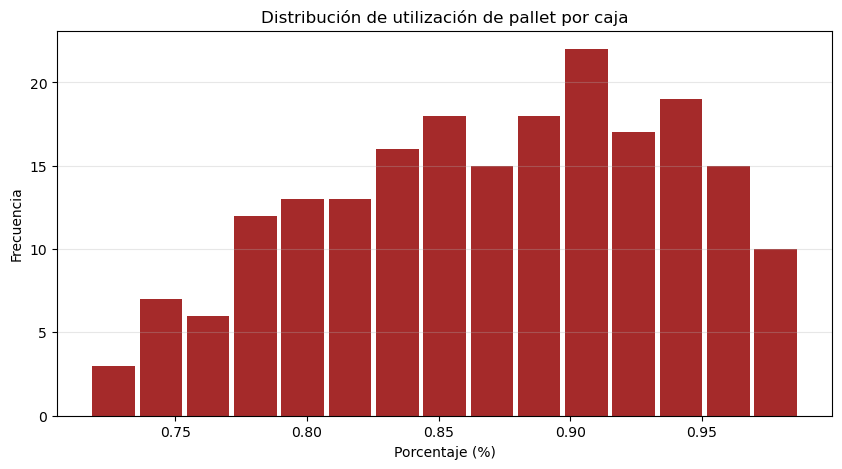

In [447]:
plt.figure(figsize=(10, 5))
plt.hist(especificaciones_cajas['utilizacion'].dropna(), bins=15,
         color='brown', rwidth=0.9)
plt.title('Distribución de utilización de pallet por caja')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

Notemos que de los 204 tipos de cajas, la mayoría realmente no tiene un uso eficiente del espacio de pallet. Si bien vemos que algunos ocupan en un 90% o más, hay otros que apenas alcanzan al 75%; y la mitad alternan entre un 80% y 90%, lo cual demuestra que el uso de ciertos tipos de cajas se ve más beneficiado que de otros.

#### **4. Volumen de productos y cajas por planta**

In [448]:
def resumen_por_planta(df, prefijo, titulo):
    cols = [c for c in df.columns if c.startswith(prefijo)] # Filtramos por las plantas
    sums = {}
    for c in cols:
        vals = pd.to_numeric(df[c], errors='coerce').fillna(0)
        sums[c.replace(prefijo, '')] = vals.sum() # Sumamos cada volumen de producto/caja
    
    serie = pd.Series(sums).sort_values(ascending=False) # Sorteamos de mayor a menor
    
    # Imprimimos la información
    print(titulo)
    print("-" * 35)
    for planta, total in serie.items():
        print(f"{planta:15s} {total:12}")

resumen_por_planta(operaciones_planta, 'volumen_producto_planta_', "Productos enviados por planta")
print("\n")
resumen_por_planta(procurement_cajas, 'volumen_tipo_planta_', "Cajas enviadas por planta")

Productos enviados por planta
-----------------------------------
curitiba            24919776
santiago            16349368
buenos_aires        10944695
bakersfield          9694072
monterrey            8207855


Cajas enviadas por planta
-----------------------------------
curitiba           106682302
santiago            71075654
monterrey           45648038
bakersfield         41373865
buenos_aires        32902485
curitiba_requerido     24919776
santiago_requerido     16349368
buenos_aires_requerido     10944695
bakersfield_requerido      9694072
monterrey_requerido      8207855


Observemos que las plantas de Curitiba y Santiago son las que reciben más productos y cajas en general. En el caso de Curitiba, la diferencia supera el doble frente a las demás tres plantas. Esto puede suponer una mayor conveniencia para enviar unidades a Curitiba, debido a los altos descuentos en el costo.

Veamos en más profundidad la variación de descuentos según la planta.

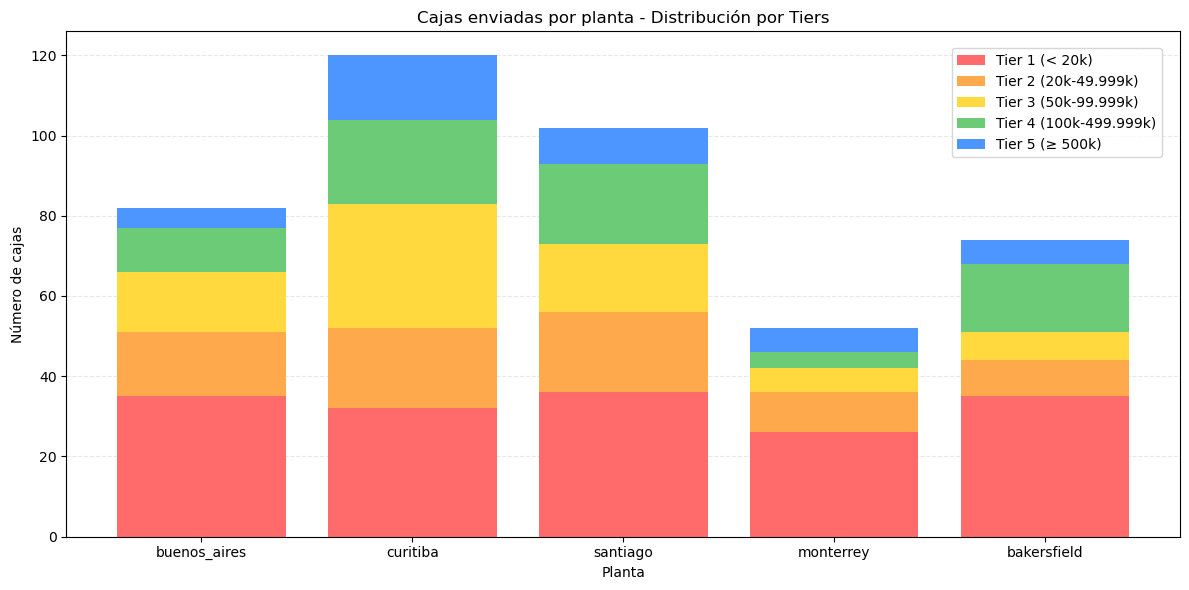

In [449]:
def clasificar_tier(descuento):
    """ Clasifica el volumen en tiers según las reglas definidas. """
    if descuento == 0.1:
        return 'Tier 1 (< 20k)'
    elif descuento == 0:
        return 'Tier 2 (20k-49.999k)'
    elif descuento == -0.1:
        return 'Tier 3 (50k-99.999k)'
    elif descuento == -0.2:
        return 'Tier 4 (100k-499.999k)'
    else:
        return 'Tier 5 (≥ 500k)'

cols = [c for c in procurement_cajas.columns if c.startswith('descuento_planta_') and not c.endswith('original')]
resultados = {}

for c in cols:
    planta = c.replace('descuento_planta_', '')
    col_volumen = f'volumen_tipo_planta_{planta}'
    
    # Obtener valores
    descuentos = pd.to_numeric(procurement_cajas[c], errors='coerce').fillna(0)
    volumenes = pd.to_numeric(procurement_cajas[col_volumen], errors='coerce').fillna(0)
    
    descuentos_filtrados = descuentos[volumenes > 0] # Solo contar si volumen > 0
    
    # Clasificar cada valor en tiers
    tiers = [clasificar_tier(d) for d in descuentos_filtrados]
    
    # Contar tiers para esta planta
    if tiers:
        conteo_tiers = pd.Series(tiers).value_counts()
        resultados[planta] = conteo_tiers
    else:
        resultados[planta] = pd.Series()

df_resultados = pd.DataFrame(resultados).fillna(0).T

# Ordenar columnas de tiers
orden_tiers = ['Tier 1 (< 20k)', 'Tier 2 (20k-49.999k)', 
               'Tier 3 (50k-99.999k)', 'Tier 4 (100k-499.999k)', 
               'Tier 5 (≥ 500k)']

df_resultados = df_resultados.reindex(columns=orden_tiers, fill_value=0)

# Gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(12, 6))

colores = ['#FF6B6B', '#FFA94D', '#FFD93D', '#6BCB77', '#4D96FF']

bottom = np.zeros(len(df_resultados))
for i, tier in enumerate(orden_tiers):
    if tier in df_resultados.columns:
        ax.bar(df_resultados.index, df_resultados[tier], 
               bottom=bottom, label=tier, color=colores[i])
        bottom += df_resultados[tier].values

# Personalizar gráfico
ax.set_xlabel('Planta')
ax.set_ylabel('Número de cajas')
ax.set_title('Cajas enviadas por planta - Distribución por Tiers')
ax.legend(bbox_to_anchor=(0.99, 0.98))
ax.tick_params(axis='x')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

<span style="font-family: 'Calibri', monospace; font-size: 17px;">

Mediante el gráfico, podemos encontrar dos hallazgos clave que respaldan lo mencionado anteriormente:

1. Las plantas de Curitiba y Santiago destacan por ser las que reciben la mayor cantidad de tipos de cajas. Por el contrario, Monterrey presenta el menor nivel de actividad, con una recepción considerablemente más baja.

2. Un porcentaje relevante de los tipos de cajas enviados a Curitiba y Santiago superan las 500k unidades, o al menos alcanzan las 100k unidades. Esto implica que dichas plantas califican para los descuentos más altos en el costo de flete, y sumando además a que hay un gran volumen de productos en esas plantas, lo visto representa evidentemente una ventaja logística significativa.

Observaciones adicionales:

- Todas las plantas presentan una cantidad similar de tipos de cajas con volúmenes bajos (menos de 20k unidades).

- Ciertamente, Bakersfield tiene un número considerable de tipos de cajas con volúmenes altos, ubicados en los Tiers 1 y 2.

</span>

#### **5. Análisis de resistencia a compresión**

Antes de realizar un análisis sobre la resistencia y la carga de peso permitida por cada producto, comprobemos que en la situación actual cada producto soporta el peso de las capas apiladas en el pallet.

Empecemos a calcular la carga máxima soportada por cada tipo de caja (kg), cuya fórmula está dada por:

$$
carga_{\text{máx}} (\text{kg}) = \frac{ECT (\text{N/m}) \times \text{perímetro}_{\text{caja}} (\text{m})}{9.81 (m/s^2)}
$$

In [450]:
# Calculamos primero el perímetro
perimetro_cajas = (especificaciones_cajas["caja_exterior_largo"] + 
                   especificaciones_cajas["caja_exterior_ancho"]) * 2 / 1000 # Dividimos por 1000 para pasar de mm a m

# Correspondencia grosor-ect
ect_por_grosor = {2.5: 600, 2.7: 730, 3.0: 1000, 4.1: 1200, 4.5: 1400, 4.6: 1450, 4.7: 1500, 4.8: 1550, 5.0: 1650}
ects = [ect_por_grosor[g] for g in especificaciones_cajas['caja_grosor_mm']]

# Aplicamos la fórmula de carga máxima
especificaciones_cajas['carga_max'] = ects * perimetro_cajas / 9.81

Calculemos la carga soportada por cada producto actualmente.

In [451]:
prod_caja_merge = catalogo_productos.merge(especificaciones_cajas,
                                           on='caja_tipo_id',
                                           how='left')

# Restamos -1 para NO contar la caja de la base
prod_caja_merge['carga_soportada'] = prod_caja_merge['peso_neto_caja'] * (prod_caja_merge['cantidad_cajas_alto'] - 1)

Ahora veamos si las cajas soportan realmente el peso de las capas apiladas.

In [452]:
no_soportan = prod_caja_merge['carga_soportada'] > prod_caja_merge['carga_max']

# Verificar
if no_soportan.sum() == 0:
    print("Todas las cajas soportan el peso.")
else:
    print(f"{no_soportan.sum()} productos NO cumplen con la capacidad de carga.")

Todas las cajas soportan el peso.


Observamos que todos los tipos de cajas soportan actualmente el peso de las capas apiladas. En particular, notemos que el número máximo de cajas que se pueden apilar para un producto dado es:

$$
n_{\text{max\_carga}} = \left\lfloor \frac{\text{carga\_max}}{\text{peso\_neto\_caja}} \right\rfloor + 1
$$

Aunque debemos tener cuidado en que este número no haga que la pila sobrepase los 1800 mm (altura del pallet).

In [453]:
# Calculemos el número máximo de cajas de carga
prod_caja_merge['n_max_carga'] = (prod_caja_merge['carga_max'] // prod_caja_merge['peso_neto_caja']) + 1

# Recordemos que 'cantidad_cajas_alto' indica la máxima cantidad de cajas que
# se pueden apilar en alto dentro del pallet

# Comparemos ahora con el número máximo permitido por la altura de pallet
# Queremos comprobar que la cantidad de capas apiladas permitida sea siempre
# menor o igual a la cantidad de carga máxima (tiene que pasar esto porque
# de lo contrario se romperían las cajas)
cumplen = prod_caja_merge['cantidad_cajas_alto'] <= prod_caja_merge['n_max_carga']

if cumplen.sum() == len(prod_caja_merge):
    print("Todas las cajas están restringidas por el número de carga máxima.")
else:
    print(f"{len(prod_caja_merge) - cumplen.sum()} cajas NO fueron restringidas por el número de carga máxima.")

Todas las cajas están restringidas por el número de carga máxima.


Según lo visto, el resultado obtenido es bastante razonable, porque sino no tendría sentido la utilización del pallet en alto. 

Lo interesante sería ahora plantear si bajando el valor de carga máxima, las cajas seguirían siendo restringidas por el número de cajas por carga máxima. Probemos esto utilizando el mínimo grosor permitido = 3.0 mm.

In [454]:
nuevo_per = (prod_caja_merge["caja_interior_largo"] + 
             prod_caja_merge["caja_interior_ancho"] + 12.0) * 2 / 1000 # Sumamos 12.0 por los 4 grosores

prod_caja_merge['carga_max_3mm'] = 1000 * nuevo_per / 9.81 # ECT de 0.3mm es 1000
prod_caja_merge['n_max_carga_3mm'] = (prod_caja_merge['carga_max_3mm'] // prod_caja_merge['peso_neto_caja']) + 1

# También recalculamos la cantidad máxima de cajas que podemos apilar en un pallet
prod_caja_merge['cantidad_cajas_alto_3mm'] = 1800 // (prod_caja_merge['caja_interior_alto'] + 6.0)

# Veamos si sigue cumpliendo todavía la restricción
cumplen = prod_caja_merge['cantidad_cajas_alto_3mm'] <= prod_caja_merge['n_max_carga_3mm']

if cumplen.sum() == len(prod_caja_merge):
    print("Todas las cajas están restringidas por el número de carga máxima.")
else:
    print(f"{len(prod_caja_merge) - cumplen.sum()} cajas NO fueron restringidas por el número de carga máxima.")

Todas las cajas están restringidas por el número de carga máxima.


Este resultado sí nos resulta interesante, porque nos dice que sin importar el grosor que elijamos (dentro de los permitidos), la cantidad de cajas que se puede apilar en un pallet en alto no se ve afectada por el número de cajas permitido por carga máxima. Podemos entonces asignar cajas a productos sin preocuparnos por la resistencia, ya que siempre se cumplirá. 

In [455]:
mas_cajas = prod_caja_merge['cantidad_cajas_alto_3mm'] > prod_caja_merge['cantidad_cajas_alto']
print(f"{mas_cajas.sum()} tipos de cajas pudieron tener más capas apiladas en el pallet.")

63 tipos de cajas pudieron tener más capas apiladas en el pallet.


De hecho, notemos que reduciendo el grosor a 3.0 mm (en algunos casos aumentando), hubo ganancia en la cantidad de capas que podemos apilar en el pallet. Esto aumenta la utilización de pallet, lo cual resulta beneficioso para el contexto de nuestro problema.

#### **6. Cajas compras no usadas**

Anteriormente en la correctitud de datos, chequeamos que efectivamente se compraron en cada planta más tipos de cajas de los que se utilizaron para cada producto. Analicemos ahora cuál es esa diferencia.

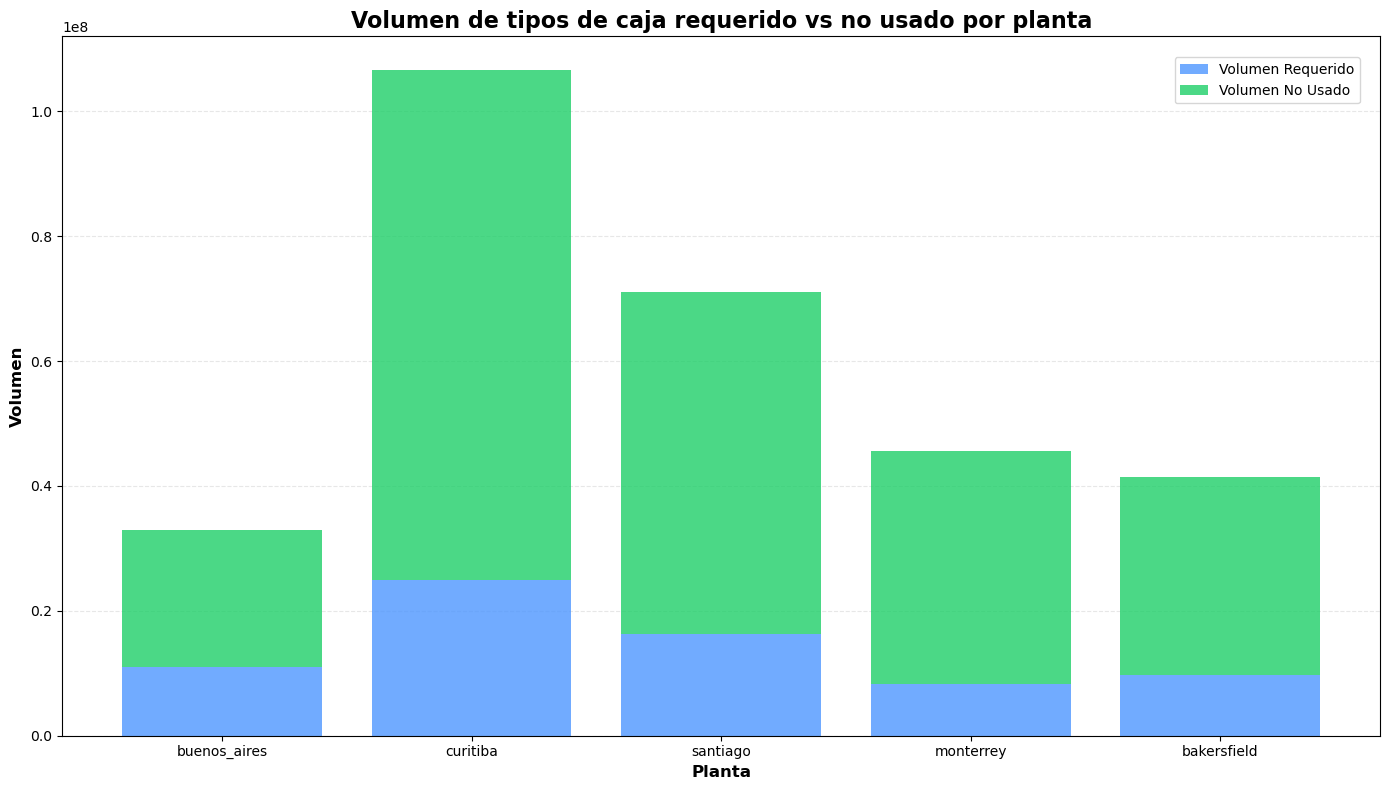

In [456]:
cols_volumen = [c for c in procurement_cajas.columns if c.startswith('volumen_tipo_planta_') and c.endswith('_requerido')]
resultados = {}

for c in cols_volumen:
    planta = c.replace('volumen_tipo_planta_', '').replace('_requerido', '')
    
    # Obtener valores
    volumen_requerido_col = f'volumen_tipo_planta_{planta}_requerido'
    volumen_comprado_col = f'volumen_tipo_planta_{planta}'
    
    # Sumar volúmenes por planta
    volumen_requerido = procurement_cajas[volumen_requerido_col].sum()
    volumen_comprado = procurement_cajas[volumen_comprado_col].sum()
    
    # Calcular diferencia (no requerido)
    diferencia = max(0, volumen_comprado - volumen_requerido)
    
    resultados[planta] = {
        'requerido': volumen_requerido,
        'no_usado': diferencia,
        'total': volumen_comprado
    }

df_resultados = pd.DataFrame(resultados).T
df_resultados.columns = ['requerido', 'no_usado', 'total']

# Gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(14, 8))
colores = ["#4D96FF", "#1ecf68"]
labels = ['Volumen Requerido', 'Volumen No Usado']

bottom = np.zeros(len(df_resultados))
# Barra 1: Volumen requerido
ax.bar(df_resultados.index, df_resultados['requerido'], 
       bottom=bottom, label=labels[0], color=colores[0], alpha=0.8)
bottom += df_resultados['requerido'].values
# Barra 2: Volumen sin usar
ax.bar(df_resultados.index, df_resultados['no_usado'], 
       bottom=bottom, label=labels[1], color=colores[1], alpha=0.8)

# Personalizar gráfico
ax.set_xlabel('Planta', fontsize=12, fontweight='bold')
ax.set_ylabel('Volumen', fontsize=12, fontweight='bold')
ax.set_title('Volumen de tipos de caja requerido vs no usado por planta', fontsize=16, fontweight='bold')
ax.legend(bbox_to_anchor=(0.99, 0.98))
ax.tick_params(axis='x')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Evidentemente, la diferencia es notablemente alta, es decir que quedan muchos tipos de cajas comprados que se desperdician. Esto demuestra la importancia del problema, y explica por qué resulta relevante reducir la cantidad de tipos de cajas.

Analicemos más en profundidad el caso de Curitiba, que es la que presenta mayor diferencia.

In [457]:
procurement_cajas['diferencia_volumen_curitiba'] = (
    procurement_cajas['volumen_tipo_planta_curitiba'] - procurement_cajas['volumen_tipo_planta_curitiba_requerido']
)

procurement_cajas[['volumen_tipo_planta_curitiba_requerido', 
                   'volumen_tipo_planta_curitiba', 
                   'diferencia_volumen_curitiba']].sort_values('diferencia_volumen_curitiba', ascending=False)

,volumen_tipo_planta_curitiba_requerido,volumen_tipo_planta_curitiba,diferencia_volumen_curitiba
190,1975933,21735263,19759330
157,2574505,18021535,15447030
170,813881,6511048,5697167
88,1218108,6090540,4872432
38,1155287,5776435,4621148
...,...,...,...
197,0,0,0
199,0,0,0
198,0,0,0
201,0,0,0


Podemos ver que la cantidad de desperdicio se concentra mayormente en solamente algunos tipos de cajas. Más de 2/3 de éstos no presenta ninguna diferencia entre el volumen requerido y el comprado.

Podemos intuir entonces que elegir con más prioridad aquellos tipos de cajas con mayor índice de desperdicio, podría llegar a generar cierta eficiencia en el ahorro de costos y cajas.